In [1]:
import numpy as onp
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from chainconsumer import Chain, ChainConsumer, Truth, ChainConfig, PlotConfig

In [2]:
import corner
import matplotlib.lines as mlines

from matplotlib.ticker import MaxNLocator
from matplotlib.colors import to_rgba
from scipy.ndimage import gaussian_filter

# Load the posterior samples (get posterior files from the zenodo repo)

In [3]:
# Ringdown samples

event_id = "GW190521"

posterior_full_sky  = onp.load('./posterior_files/full-sky/posterior.' + event_id + '.full-sky.npy')
posterior_fixed_sky = onp.load('./posterior_files/fixed-sky/posterior.' + event_id + '.fixed-sky.npy')

In [4]:
# IMR samples
# Using samples from NRSur7dq4 run

with h5py.File("./posterior_files/GW190521_posterior_samples.h5", "r") as f:
    post_samples = f['NRSur7dq4']['posterior_samples'][:]


ra_imr = post_samples['ra']
sindec_imr = onp.sin(post_samples['dec'])

samples_IMR = onp.array([ra_imr, sindec_imr]).T

# Corner plot comparing Full-sky and Fixed-sky

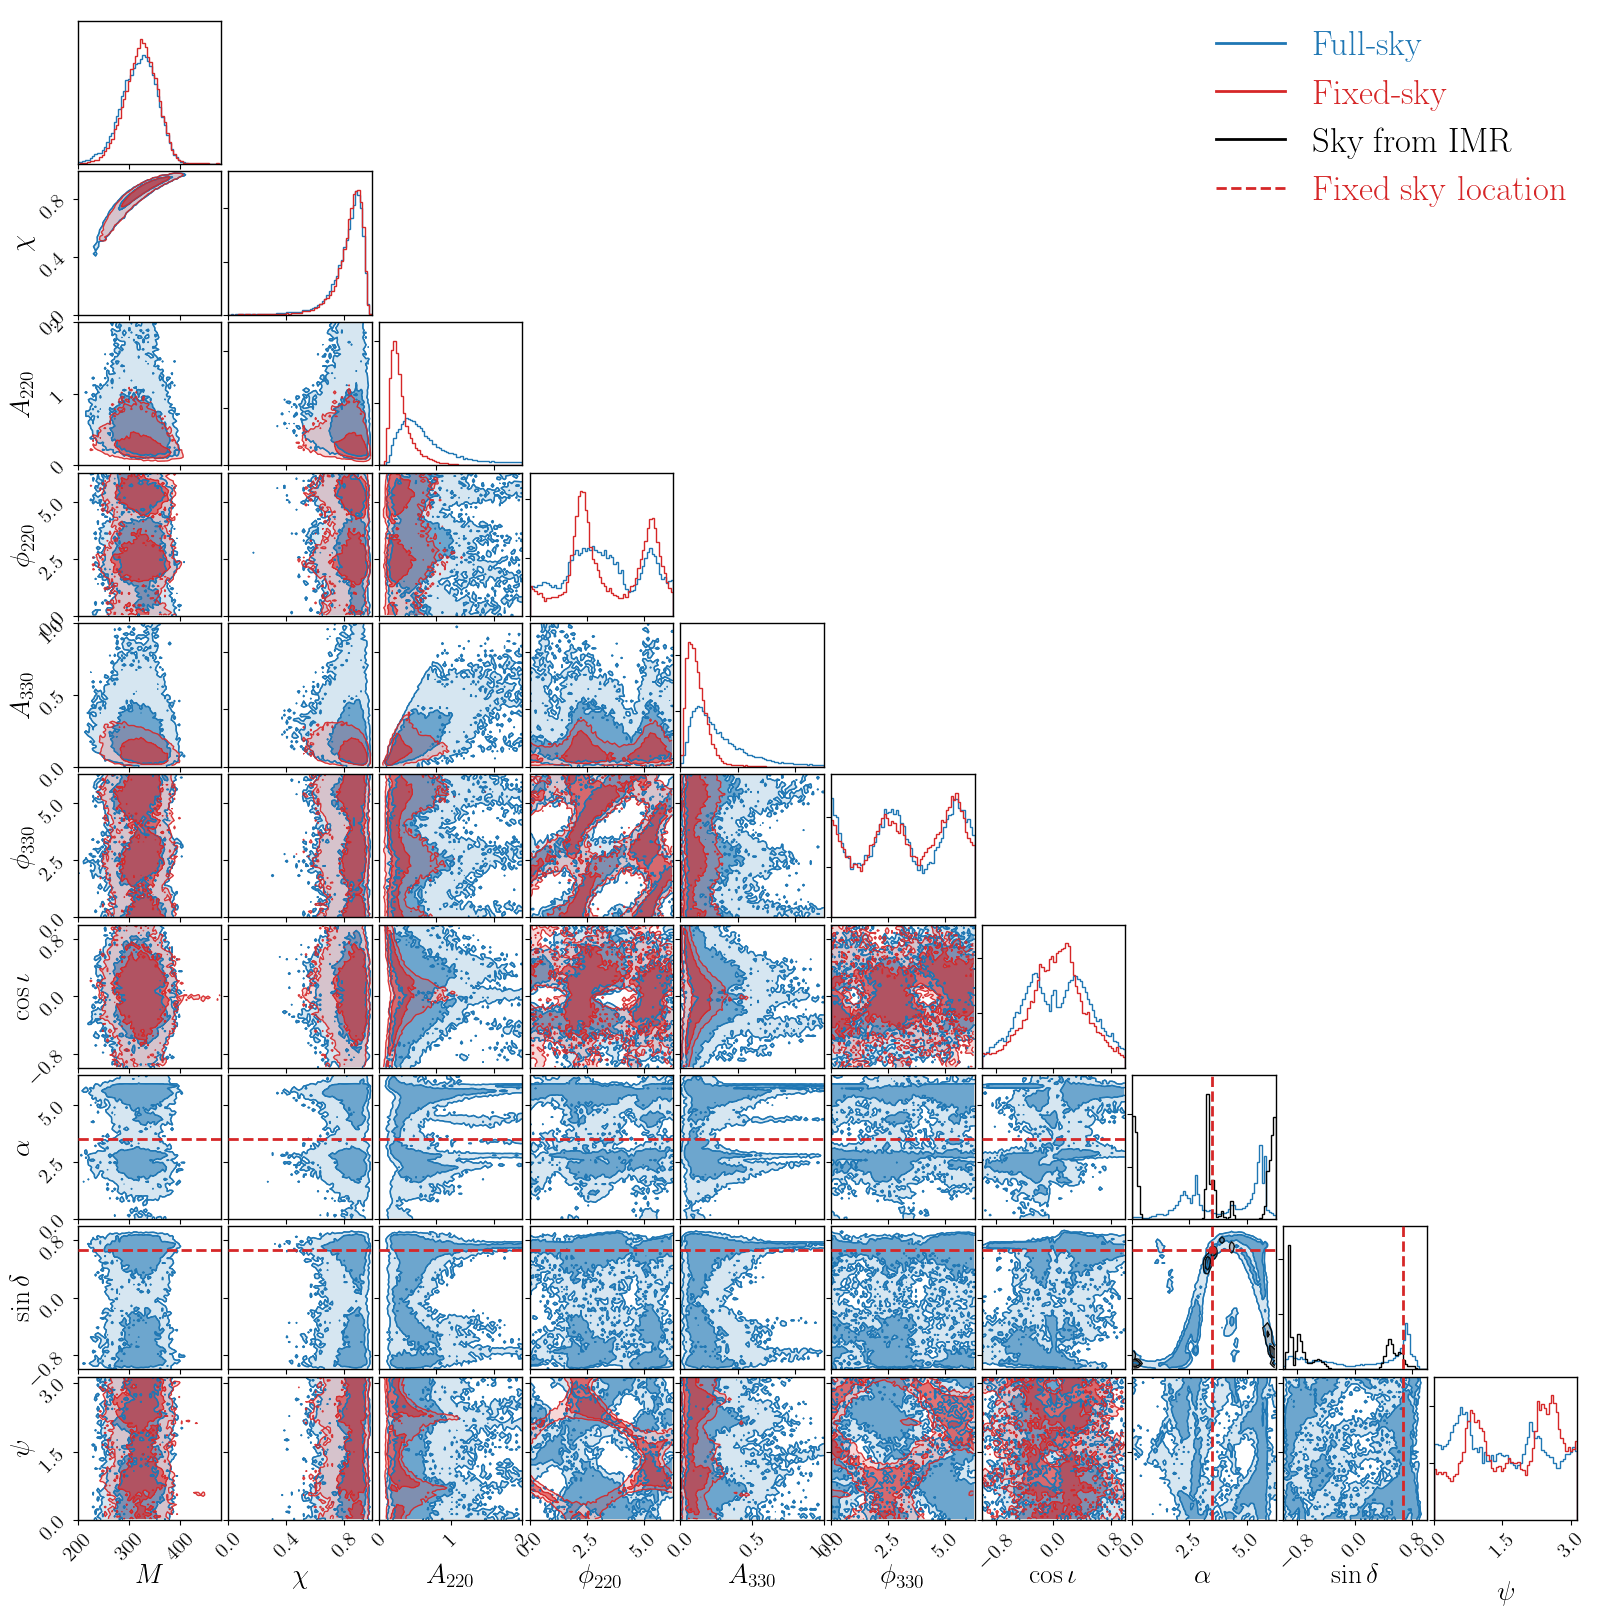

In [5]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 10,
    "axes.grid": False,
    "axes.linewidth": 1,
})

full_sky_params = [
    r'$M$', r'$\chi$', r'$A_{220}$', r'$\phi_{220}$',
    r'$A_{330}$', r'$\phi_{330}$', r'$\cos\iota$',
    r'$\alpha$', r'$\sin \delta$', r'$\psi$'
]

fixed_sky_params = [
    r'$M$', r'$\chi$', r'$A_{220}$', r'$\phi_{220}$',
    r'$A_{330}$', r'$\phi_{330}$', r'$\cos\iota$', r'$\psi$'
]

sky_params = [r'$\alpha$', r'$\sin \delta$']

bounds = {
    r'$M$': (200.0, 480.0),
    r'$\chi$': (0.0, 0.99),
    r'$A_{220}$': (0.0, 2.0),
    r'$\phi_{220}$': (0.0, 2 * onp.pi),
    r'$A_{330}$': (0.0, 1.0),
    r'$\phi_{330}$': (0.0, 2 * onp.pi),
    r'$\cos\iota$': (-1.0, 1.0),
    r'$\alpha$': (0.0, 6.28),
    r'$\sin \delta$': (-1.0, 1.0),
    r'$\psi$': (0.0, 3.14),
}

df_full_sky = pd.DataFrame(posterior_full_sky, columns=full_sky_params)
df_fixed_sky_inj = pd.DataFrame(posterior_fixed_sky, columns=fixed_sky_params)


df_sky_only = pd.DataFrame(samples_IMR, columns=sky_params)

ranges = [bounds[p] for p in full_sky_params]

samples_full = df_full_sky[full_sky_params].values
samples_fixed_inj = df_fixed_sky_inj[fixed_sky_params].values
samples_sky_only = df_sky_only[sky_params].values

fig = corner.corner(
    samples_full,
    labels=full_sky_params,
    range=ranges,
    color="#1f77b4",
    bins=60,
    smooth=None,
    plot_datapoints=False,
    plot_density=False,
    plot_contours=True,
    fill_contours=False,
    levels=(0.683, 0.954),
    label_kwargs={"fontsize": 20},
    hist_kwargs={"linewidth": 1., "histtype": "step", "density": True},
    contour_kwargs={"linewidths": 1.},
    show_titles=False,
)

fig.set_size_inches(16, 16)

ndim = len(full_sky_params)
axes = onp.array(fig.axes).reshape((ndim, ndim))

shared_params = fixed_sky_params
shared_inds = [full_sky_params.index(p) for p in shared_params]

sky_inds = [full_sky_params.index(p) for p in sky_params]


def density_hist(x, param, bins=60):
    return onp.histogram(
        x,
        bins=bins,
        range=bounds[param],
        density=True,
    )


diag_ymax = {}

for i, p in enumerate(full_sky_params):
    ax = axes[i, i]
    ax.cla()

    ymax = 0.0

    h, edges = density_hist(df_full_sky[p].values, p)
    ymax = max(ymax, onp.nanmax(h))
    ax.stairs(h, edges, color="#1f77b4", linewidth=1.)

    if p in fixed_sky_params:
        h, edges = density_hist(df_fixed_sky_inj[p].values, p)
        ymax = max(ymax, onp.nanmax(h))
        ax.stairs(h, edges, color="#d62728", linewidth=1.)

    if p in sky_params:
        h, edges = density_hist(df_sky_only[p].values, p)
        ymax = max(ymax, onp.nanmax(h))
        ax.stairs(h, edges, color="#000000", linewidth=1.)

    ax.set_xlim(bounds[p])
    ax.set_ylim(0.0, 1.15 * ymax)
    ax.set_yticks([])
    diag_ymax[p] = 1.15 * ymax


def get_levels_from_probs(H, probs=(0.954, 0.683)):
    Hflat = H.flatten()
    Hflat = Hflat[onp.isfinite(Hflat)]

    if Hflat.size == 0 or Hflat.max() <= 0:
        return None

    Hsort = onp.sort(Hflat)[::-1]
    cumsum = onp.cumsum(Hsort)
    cumsum /= cumsum[-1]

    levels = []
    for p in probs:
        levels.append(Hsort[onp.searchsorted(cumsum, p)])

    return onp.sort(levels)


def filled_contours(samples, color, param_list, inds,
                    alpha_outer=0.18, alpha_inner=0.65):
    for a, i in enumerate(inds):
        for b, j in enumerate(inds[:a]):

            x = samples[:, b]
            y = samples[:, a]

            xb = bounds[param_list[b]]
            yb = bounds[param_list[a]]

            H, xedges, yedges = onp.histogram2d(
                x,
                y,
                bins=60,
                range=[xb, yb],
                density=True,
            )

            levels = get_levels_from_probs(H, probs=(0.954, 0.683))
            if levels is None:
                continue

            vmax = onp.nanmax(H)
            if not onp.isfinite(vmax) or vmax <= levels[-1]:
                continue

            xcenters = 0.5 * (xedges[1:] + xedges[:-1])
            ycenters = 0.5 * (yedges[1:] + yedges[:-1])

            ax = axes[i, j]

            ax.contourf(
                xcenters,
                ycenters,
                H.T,
                levels=[levels[0], levels[1], vmax],
                colors=[
                    to_rgba(color, alpha_outer),
                    to_rgba(color, alpha_inner),
                ],
                zorder=1,
            )

            ax.contour(
                xcenters,
                ycenters,
                H.T,
                levels=levels,
                colors=[color],
                linewidths=1.,
                alpha=0.9,
                zorder=2,
            )


filled_contours(samples_full, "#1f77b4", full_sky_params, list(range(ndim)))
filled_contours(samples_fixed_inj, "#d62728", shared_params, shared_inds)

filled_contours(samples_sky_only, "#000000", sky_params, sky_inds)

i_alpha = full_sky_params.index(r'$\alpha$')
i_sindelta = full_sky_params.index(r'$\sin \delta$')

fix_sky_loc = {
    i_alpha: 3.5,
    i_sindelta: onp.sin(0.73),
}

for i in range(ndim):
    for j in range(i + 1):  # lower triangle + diagonal
        ax = axes[i, j]

        if j in fix_sky_loc:
            ax.axvline(
                fix_sky_loc[j],
                color="#d62728",
                linestyle="--",
                linewidth=2.0,
                zorder=101,
            )

        if i != j and i in fix_sky_loc:
            ax.axhline(
                fix_sky_loc[i],
                color="#d62728",
                linestyle="--",
                linewidth=2.0,
                zorder=101,
            )

axes[i_sindelta, i_alpha].plot(
    fix_sky_loc[i_alpha],
    fix_sky_loc[i_sindelta],
    marker="X",
    color="#d62728",
    markersize=5,
    linestyle="None",
    zorder=102,
)

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]

        if i < j:
            ax.set_visible(False)
            continue

        ax.set_xlim(bounds[full_sky_params[j]])

        if i == j:
            ax.set_ylim(0.0, diag_ymax[full_sky_params[i]])
            ax.set_yticks([])
        else:
            ax.set_ylim(bounds[full_sky_params[i]])

        if i != ndim - 1:
            ax.tick_params(axis="x", labelbottom=False)
            ax.set_xlabel("")

        if j != 0:
            ax.tick_params(axis="y", labelleft=False)
            ax.set_ylabel("")

        ax.xaxis.set_major_locator(MaxNLocator(3))
        ax.yaxis.set_major_locator(MaxNLocator(3))
        ax.tick_params(labelsize=15)
        ax.grid(False)

axes[-1, -1].set_xlabel(r'$\psi$', fontsize=20, labelpad=24)
axes[-1, -1].xaxis.set_label_coords(0.5, -0.42)

for tick in axes[-1, -1].get_xticklabels():
    tick.set_rotation(45)

axes[0, 0].set_yticks([])
axes[0, 0].set_ylabel("")
axes[0, 0].tick_params(axis="y", left=False, labelleft=False)

# manual adjustments to make sure tick labels do not overlap
axes[-1,4].set_xticks([0.0, 0.5, 1.0])
axes[-1,2].set_xticks([0.0, 1.0, 2.0])
axes[4,0].set_yticks([0.0, 0.5, 1.0])
axes[2,0].set_yticks([0.0, 1.0, 2.0])

legend_handles = [
    mlines.Line2D([], [], color="#1f77b4", label="Full-sky", linewidth=2),
    mlines.Line2D([], [], color="#d62728", label="Fixed-sky", linewidth=2),
    mlines.Line2D([], [], color="#000000", label="Sky from IMR", linewidth=2),
    mlines.Line2D([], [], color="#d62728", label="Fixed sky location", linewidth=2, linestyle='--'),
]

fig.legend(
    handles=legend_handles,
    labelcolor='linecolor',
    fontsize=25,
    loc="upper right",
    frameon=False,
)
plt.savefig('./plots/GW190521.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Mode amplitude ratio for Full-sky and Fixed-sky 

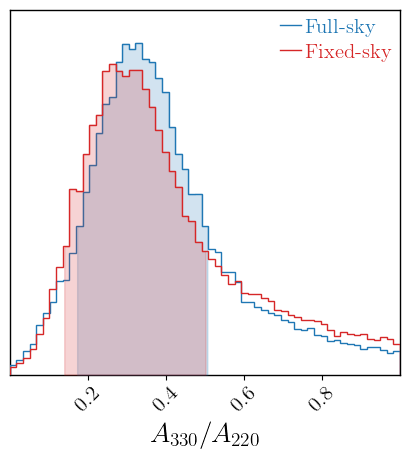

In [6]:
df_full_sky = pd.DataFrame(posterior_full_sky[:,4]/posterior_full_sky[:,2], columns=[r'$A_{330}/A_{220}$'])
df_fixed_sky = pd.DataFrame(posterior_fixed_sky[:,4]/posterior_fixed_sky[:,2], columns=[r'$A_{330}/A_{220}$'])


c = ChainConsumer()
c.add_chain(Chain(samples=df_full_sky, color='#1f77b4', name="Full-sky"))
c.add_chain(Chain(samples=df_fixed_sky, color='#d62728', name="Fixed-sky"))
c.set_override(ChainConfig(sigmas=[0, 1, 2], bins=60, smooth=0,))
c.set_plot_config(
    PlotConfig(
        usetex=1,
        serif=1,
        label_font_size=20,
        tick_font_size=15,
        contour_label_font_size=24,
        legend_kwargs={'fontsize': 15., 'loc': 'upper right'}
    )
)

fig = c.plotter.plot()
plt.savefig('./plots/GW190521_amp_ratio.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Change in mode amplitude ratio at different starting times

/var/folders/ym/96hpxg7j71d8y7qhmy0qh0p80000gn/T/ipykernel_7446/2712545569.py:103: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bf.set_xticklabels([rf'${label}$' for label in xticklabels])
/var/folders/ym/96hpxg7j71d8y7qhmy0qh0p80000gn/T/ipykernel_7446/2712545569.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


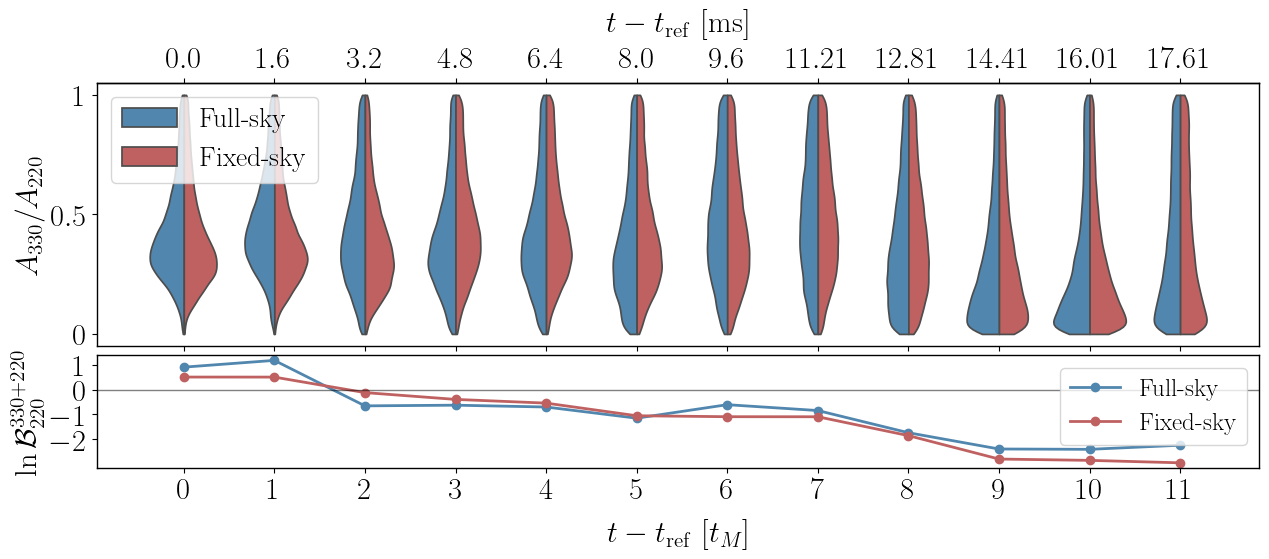

In [8]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 22,
    "axes.linewidth": 1
})

t_shifts = onp.loadtxt('./posterior_files/full-sky/GW190521-t-shift-posteriors/t_shifts.txt')
num_shifts = len(t_shifts)
violin_data = []

logZs_full_sky = onp.loadtxt('./posterior_files/full-sky/GW190521-t-shift-posteriors/logZs.txt')
logZs_220_full_sky = onp.loadtxt('./posterior_files/full-sky/GW190521-220-t-shift-posteriors/logZs_220.txt')
logBayes_330_220_full_sky = logZs_full_sky - logZs_220_full_sky

logZs_fixed_sky = onp.loadtxt('./posterior_files/fixed-sky/GW190521-t-shift-posteriors/logZs.txt')
logZs_220_fixed_sky = onp.loadtxt('./posterior_files/fixed-sky/GW190521-220-t-shift-posteriors/logZs_220.txt')
logBayes_330_220_fixed_sky = logZs_fixed_sky - logZs_220_fixed_sky


for i in range(0,num_shifts,1):

    posterior_full_sky  = onp.load('./posterior_files/full-sky/GW190521-t-shift-posteriors/posterior.' + event_id + '.' + str(i) + '.npy')
    posterior_fixed_sky = onp.load('./posterior_files/fixed-sky/GW190521-t-shift-posteriors/posterior.' + event_id + '.' + str(i) + '.npy')

    
    vals1 = posterior_full_sky[:,4]/posterior_full_sky[:,2]
    vals2 = posterior_fixed_sky[:,4]/posterior_fixed_sky[:,2]

    # xval = onp.round(t_shifts[i] * 1e3, 2)
    xval = i

    for v in vals1:
        violin_data.append({"index": f"{xval:.0f}", "value": v, "type": "Full-sky"})
    for v in vals2:
        violin_data.append({"index": f"{xval:.0f}", "value": v, "type": "Fixed-sky"})

df = pd.DataFrame(violin_data)

palette = {
    "Full-sky": "#5187ae",   # blue
    "Fixed-sky": "#c06161"   # red
}

fig, (ax, ax_bf) = plt.subplots(
    2, 1,
    figsize=(15, 5),
    sharex=True,
    gridspec_kw={"height_ratios": [3.5, 1.5], "hspace": 0.05}
)

sns.violinplot(
    data=df,
    x="index",
    y="value",
    hue="type",
    split=True,
    inner=None,
    cut=0,
    palette=palette,
    saturation=1,
    ax=ax
)

ax.legend(title=None, frameon=1, loc='upper left', fontsize=20)

ax.set_ylabel(r'$A_{330}/A_{220}$')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: rf'${y:g}$'))
# ax.set_ylim(-0.1, 4)

# Bottom subplot: log Bayes factors
x_positions = onp.arange(num_shifts)

ax_bf.plot(
    x_positions,
    logBayes_330_220_full_sky,
    marker='o',
    linewidth=2,
    label='Full-sky',
    color=palette["Full-sky"]
)

ax_bf.plot(
    x_positions,
    logBayes_330_220_fixed_sky,
    marker='o',
    linewidth=2,
    label='Fixed-sky',
    color=palette["Fixed-sky"]
)

ax_bf.axhline(0, color='k', linewidth=1, alpha=0.5)

ax_bf.set_ylabel(r'$\ln \mathcal{B}^{330+220}_{220}$')
ax_bf.set_xlabel(r'$t - t_{\mathrm{ref}}\ [t_{M}]$', labelpad=10)
ax_bf.legend(title=None, frameon=1, loc='best', fontsize=18)
ax_bf.set_yticks([-2, -1, 0, 1])
ax_bf.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: rf'${y:g}$'))

# Shared x tick labels
xticklabels = [tick.get_text() for tick in ax_bf.get_xticklabels()]
ax_bf.set_xticklabels([rf'${label}$' for label in xticklabels])

# Secondary x-axis on top of violin plot
secax = ax.secondary_xaxis('top')
secax.set_xticks(ax.get_xticks())
# secax.set_xticklabels([rf'${i}$' for i in range(num_shifts)])
secax.set_xticklabels([rf'${onp.round(t_shifts[i] * 1e3, 2)}$' for i in range(num_shifts)])
secax.set_xlabel(r'$t - t_{\mathrm{ref}}\ \mathrm{[ms]}$', labelpad=10)

plt.tight_layout()
plt.savefig('./plots/GW190521_amp_ratio_tshifts_with_logB.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
with h5py.File("./posterior_files/GW190521_posterior_samples.h5", "r") as f:
    post_samples = f['NRSur7dq4']['posterior_samples'][:]


ra_imr = post_samples['ra']
sindec_imr = onp.sin(post_samples['dec'])
tgps = post_samples['geocent_time']
H1_t = post_samples['H1_time']
L1_t = post_samples['L1_time']

samples_ = onp.array([ra_imr, sindec_imr, tgps, H1_t, L1_t]).T

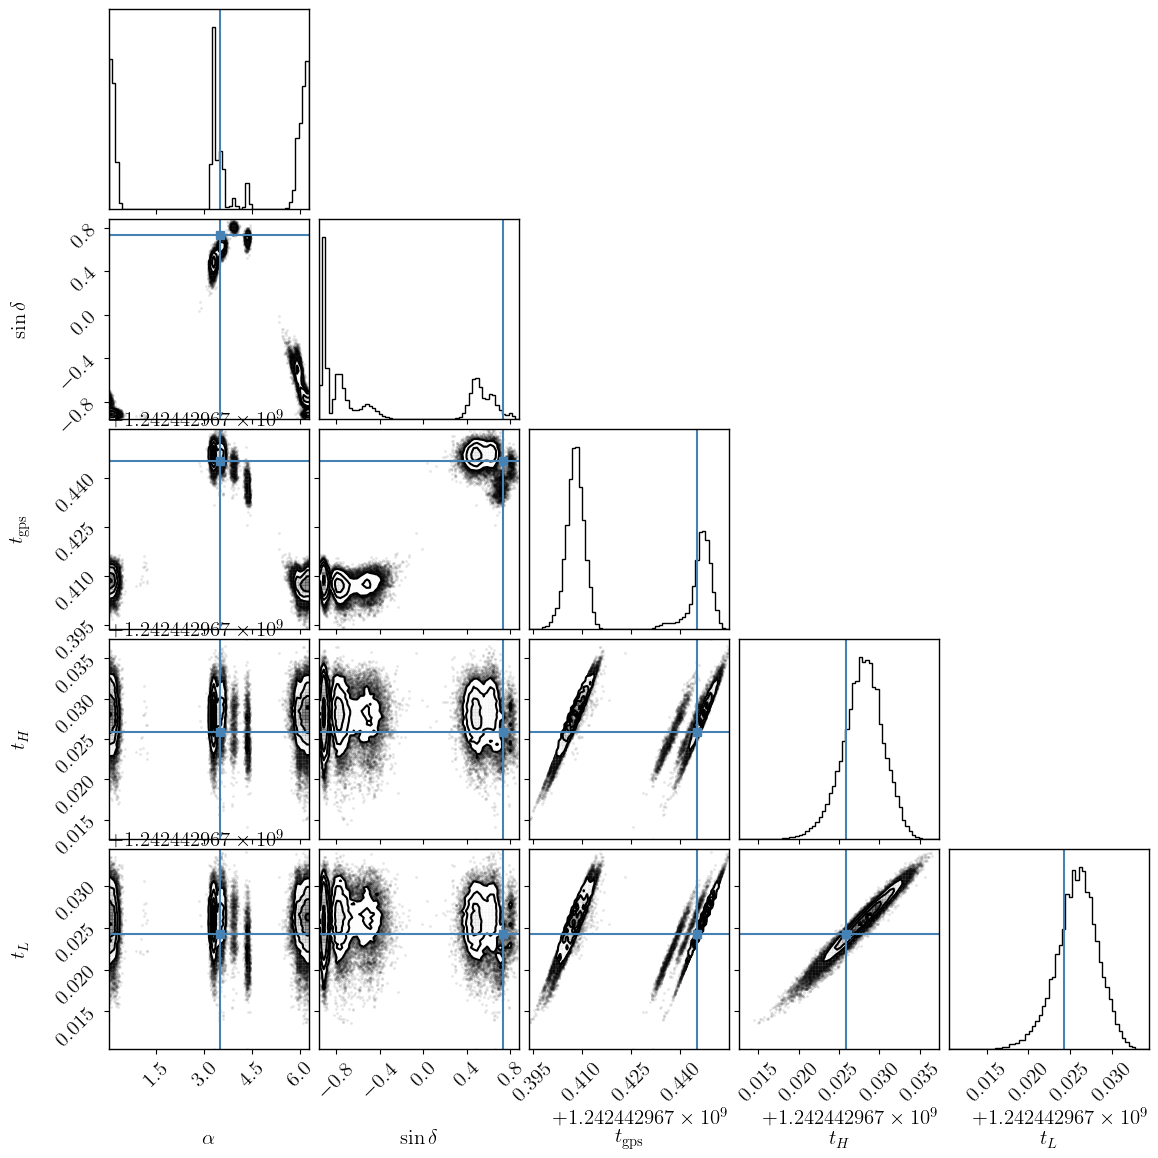

In [23]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 15,
    "axes.linewidth": 1
})

corner.corner(samples_, 
              bins=60, 
              labels=[r'$\alpha$', r'$\sin\delta$', r'$t_{\rm gps}$', r'$t_H$', r'$t_L$'],
              truths=[3.5, 0.73, 1242442967.445, 1242442967.4318974 - 0.006, 1242442967.4302728 - 0.006],
              labelpad=0.1)
plt.show()

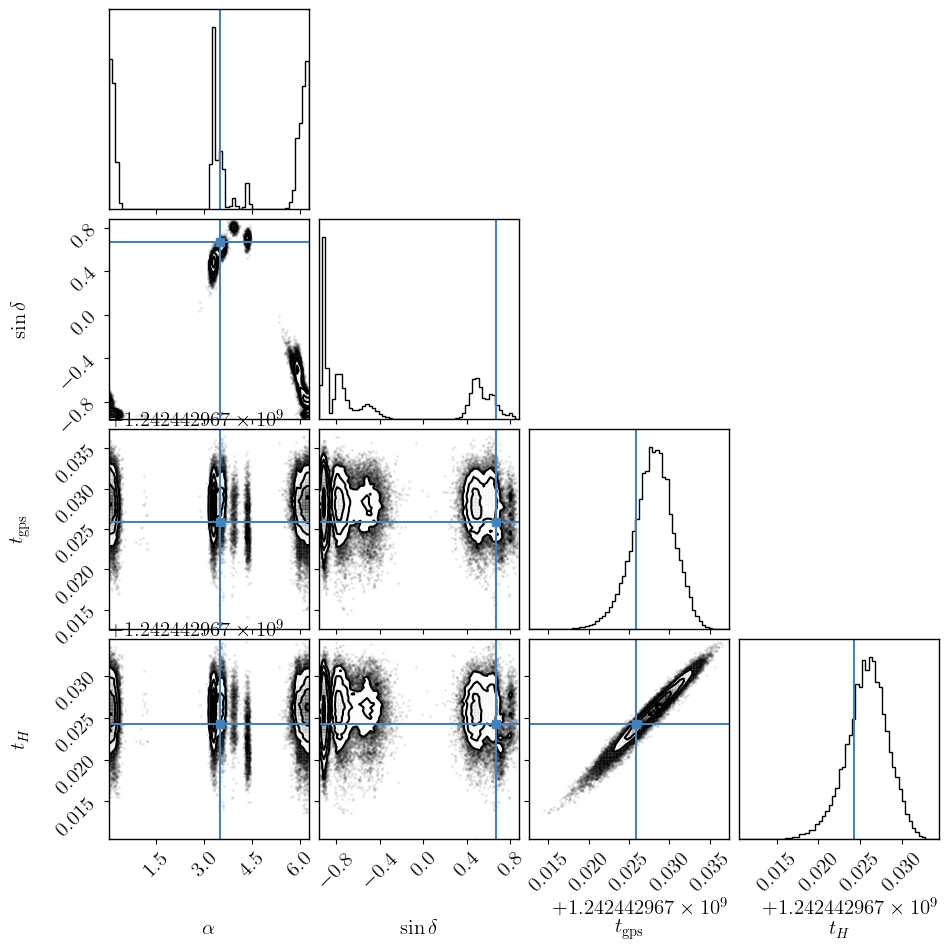

In [26]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 15,
    "axes.linewidth": 1
})

corner.corner(samples_[:,[0,1,3,4]], 
              bins=60, 
              labels=[r'$\alpha$', r'$\sin\delta$', r'$t_{\rm gps}$', r'$t_H$', r'$t_L$'],
              truths=[3.5, onp.sin(0.73), 1242442967.4318974 - 0.006, 1242442967.4302728 - 0.006],
              labelpad=0.1)
plt.show()

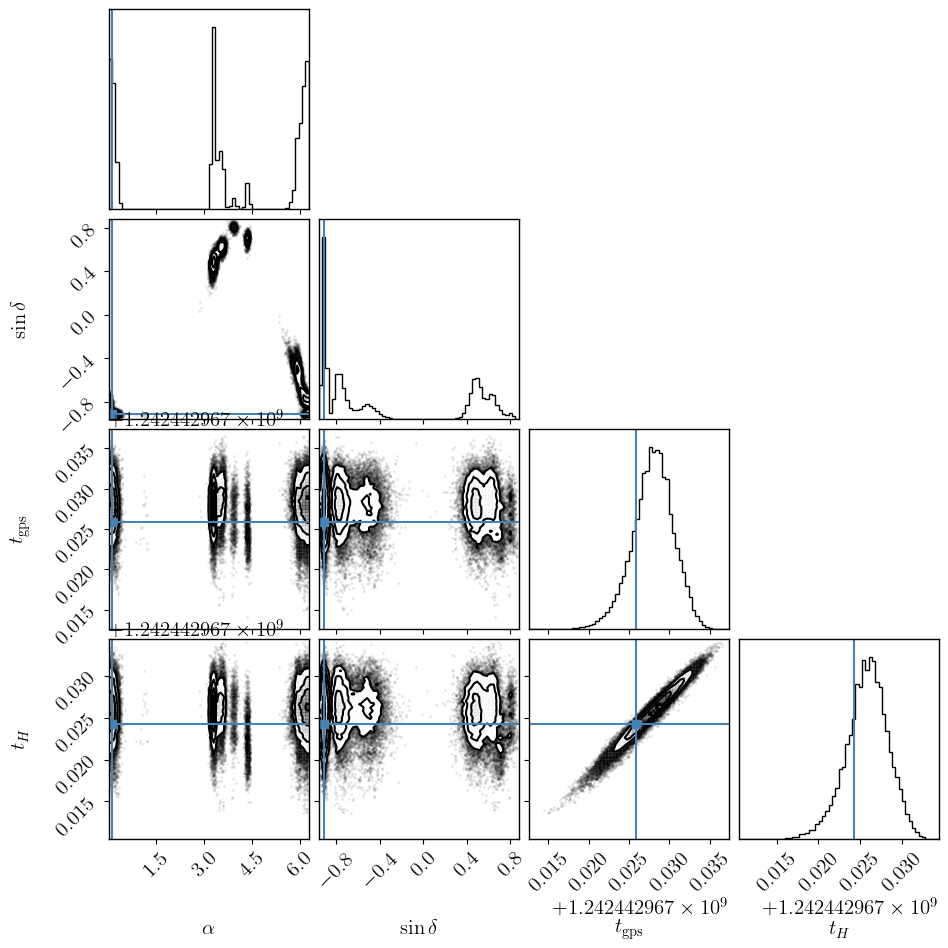

In [25]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 15,
    "axes.linewidth": 1
})

corner.corner(samples_[:,[0,1,3,4]], 
              bins=60, 
              labels=[r'$\alpha$', r'$\sin\delta$', r'$t_{\rm gps}$', r'$t_H$', r'$t_L$'],
              truths=[0.10, onp.sin(-1.14), 1242442967.4318974 - 0.006, 1242442967.4302728 - 0.006],
              labelpad=0.1)
plt.show()